**Decomposições Matriciais**
====================

**Curso:** Doutorado em Matemática Aplicada e Computacional

**Instituição:** Universidade Estadual Paulista "Júlio de Mesquita Filho" (UNESP)

**Docente:** Dr. Cássio Machiaveli Oishi

**Estudante:** Nelson Roldan Condori Colquehuanca

---

In [ ]:
# Paquetes
import numpy as np
from scipy.linalg import pascal
import pandas as pd
import time
from scipy.linalg import orth

---
#Estudo da Pseudo-inversa, usando metodos **QR**, **SVD**, **Choleski**.
---

**O siguiente Codigo é feito para una matriz Pascal**

O código compara três métodos para calcular a inversa ($X \approx A^{−1}$) de matrizes de Pascal simétricas (ordens $n=4,6,8$). Matrizes de Pascal são conhecidas por serem mal condicionadas (alto número de condição, $κ(A)$), o que testa a estabilidade numérica dos algoritmos.

In [ ]:
# Lista de valores para iterar
n_values = [4, 6, 8]

# Lista donde guardaremos os resultados
errors_data = []
residuals_data = []

for n in n_values:
    # Create the Pascal matrix
    A = pascal(n, kind='symmetric')
    X = np.linalg.inv(A)
    e_M = 2.220446049250313e-16
    k_2A = np.linalg.cond(A, 2)

    # Cholesky
    M = A.T @ A
    L = np.linalg.cholesky(M)
    R = L.T
    X_chol = np.linalg.inv(R) @ np.linalg.inv(R.T) @ A.T

    # QR
    Q_qr, R_qr = np.linalg.qr(A)
    X_qr = np.linalg.inv(R_qr) @ Q_qr.T

    # SVD
    U, S, V = np.linalg.svd(A)
    X_svd = V.T @ np.diag(1 / S) @ U.T

    # Calculo de erros
    e_chol = (np.linalg.norm(X_chol - X, 2)) / (np.linalg.norm(X, 2) * e_M * k_2A)
    e_qr = (np.linalg.norm(X_qr - X, 2)) / (np.linalg.norm(X, 2) * e_M * k_2A)
    e_svd = (np.linalg.norm(X_svd - X, 2)) / (np.linalg.norm(X, 2) * e_M * k_2A)

    errors_data.append([n, e_chol, e_qr, e_svd])

    # Calculo de Residuos
    res_chol = np.linalg.norm(X_chol @ A - np.identity(n), 2) / (np.linalg.norm(A, 2) * np.linalg.norm(X_chol, 2))
    res_qr = np.linalg.norm(X_qr @ A - np.identity(n), 2) / (np.linalg.norm(A, 2) * np.linalg.norm(X_qr, 2))
    res_svd = np.linalg.norm(X_svd @ A - np.identity(n), 2) / (np.linalg.norm(A, 2) * np.linalg.norm(X_svd, 2))

    residuals_data.append([n, res_chol, res_qr, res_svd])

# Creamos e imprimimos a tabela de erros
errors_df = pd.DataFrame(errors_data, columns=['n', 'Cholesky', 'QR', 'SVD'])
print("Tabela de Erros Relativos:")
print(errors_df)

# Creamos e imprimimos os valores residuais
residuals_df = pd.DataFrame(residuals_data, columns=['n', 'Cholesky', 'QR', 'SVD'])
print("\nTabela de Residuos:")
print(residuals_df)

Tabela de Erros Relativos:
   n      Cholesky        QR       SVD
0  4      5.870228  0.075700  0.064548
1  6   3180.088610  0.033904  0.050769
2  8  99015.393079  0.014358  0.004221

Tabela de Residuos:
   n      Cholesky            QR           SVD
0  4  9.797203e-15  4.864344e-17  7.187024e-17
1  6  4.733646e-12  4.626299e-17  2.661360e-17
2  8  2.049603e-10  2.808308e-17  3.382292e-17


A teoria é confirmada. A decomposição de Cholesky, ao depender das equações normais ($A^{T}A$), propaga erros de forma explosiva em matrizes mal condicionadas, enquanto $QR$ e $SVD$ demonstram estabilidade superior, como previsto. Todos os métodos mantiveram resíduos normalizados baixos, mas o erro real da inversa calculada por Cholesky foi ordens de magnitude maior

**O siguiente codigo e feito para uma matriz Random**

Calcular a pseudo-inversa $X=A^{+}$ para matrizes retangulares sobredeterminadas ($A\in\mathbb{R}^{3n×n}$)

In [ ]:
# Valores de n para iterar
n_values = [4, 6, 8,10]

# Lista onde guardaremos os resultados
errors_data = []
residuals_data = []

for n in n_values:
    # Creação da Matriz
    A = np.random.rand(3*n, n)

    # Solução de referencia
    X = np.linalg.pinv(A)

    # Constante para o calculo do erro
    e_M = np.finfo(float).eps # Machine epsilon
    k_2A = np.linalg.cond(A, 2) # Número de condição de A

# Cholesky
    # M simétrica y (generalmente) definida positiva
    M = A.T @ A

    # Descomposición de Cholesky: M = L @ L.T
    L = np.linalg.cholesky(M)
    R = L.T
    X_chol = np.linalg.inv(R) @ np.linalg.inv(R.T) @ A.T

# Descomposição QR
    Q_qr, R_qr = np.linalg.qr(A, mode='reduced') # Usamos QR reducida
    X_qr = np.linalg.inv(R_qr) @ Q_qr.T

# Descomposição SVD
    # Usamos SVD reducida
    U_svd, S_svd, Vh_svd = np.linalg.sreducidull_matrices=False)
    # S_svd é um vetor 1D de valores singulares, então creamos la matriz diagonal inversa.
    S_inv_diag = np.diag(1/S_svd)
    X_svd = Vh_svd.T @ S_inv_diag @ U_svd.T

    # Cálculo de Erros
    e_chol = (np.linalg.norm(X_chol - X, 2)) / (np.linalg.norm(X, 2) * e_M * k_2A)
    e_qr = (np.linalg.norm(X_qr - X, 2)) / (np.linalg.norm(X, 2) * e_M * k_2A)
    e_svd = (np.linalg.norm(X_svd - X, 2)) / (np.linalg.norm(X, 2) * e_M * k_2A)

    errors_data.append([n, e_chol, e_qr, e_svd])

    # Cálculo de Residuos
    norm_A = np.linalg.norm(A, 2)
    I_n = np.identity(n) # Matriz identidade de dimensões n x n

    res_chol = np.linalg.norm(X_chol @ A - I_n, 2) / (norm_A * np.linalg.norm(X_chol, 2))
    res_qr = np.linalg.norm(X_qr @ A - I_n, 2) / (norm_A * np.linalg.norm(X_qr, 2))
    res_svd = np.linalg.norm(X_svd @ A - I_n, 2) / (norm_A * np.linalg.norm(X_svd, 2))

    residuals_data.append([n, res_chol, res_qr, res_svd])

# Print dos Resultados

# Tabela de erros
errors_df = pd.DataFrame(errors_data, columns=['n', 'Cholesky', 'QR', 'SVD'])
print("Tabela de Erros Relativos (respecto a pinv):")
print(errors_df.to_string(float_format="%.5e")) # Formato científico para ver mejor

# Tabela de valores residuais
residuals_df = pd.DataFrame(residuals_data, columns=['n', 'Cholesky', 'QR', 'SVD'])
print("\nTabela de Residuos (norm(X@A - I) / (norm(A)*norm(X))):")
print(residuals_df.to_string(float_format="%.5e")) # Formato científico

Tabela de Erros Relativos (respecto a pinv):
    n    Cholesky          QR         SVD
0   4 7.54066e-01 5.36479e-01 7.54707e-02
1   6 2.63971e+00 2.24474e+00 7.09603e-02
2   8 1.49889e+00 1.47758e+00 7.44634e-02
3  10 1.23257e+00 4.62608e-01 4.07024e-02

Tabela de Residuos (norm(X@A - I) / (norm(A)*norm(X))):
    n    Cholesky          QR         SVD
0   4 3.95055e-16 8.93860e-17 1.94672e-16
1   6 7.04538e-16 1.39696e-16 9.16577e-16
2   8 5.16235e-16 9.92104e-17 4.66216e-16
3  10 1.00350e-15 7.09753e-17 2.23554e-16


Embora todos os métodos consigam reconstruir a pseudo-inversa com baixos resíduos absolutos ($∼10^{−16}$), o $SVD$ produz consistentemente o menor erro relativo (comparado à pseudo-inversa padrão do numpy), demonstrando sua superioridade numérica para problemas de mínimos quadrados.

---
#Implementação **ST**, **TS**, **Conjugada**.
---

Avaliar a precisão da reconstrução de decomposições especializadas: Simétrica-Triangular ($A=ST$), Triangular-Simétrica ($A=TS$), e Conjugada ($A=QΓP^{T}$)

In [ ]:
import numpy as np
from scipy.linalg import orth, solve_triangular, solve
import time
import pandas as pd

**Descomposição Conjugada**

In [ ]:
def conjugate_decomposition_definitivo(A):
    """
    Calcula la Descomposición Conjugada de una matriz A (versión definitiva).
    A = Q * Gamma * P^T
    """
    m, n = A.shape
    B = A.T @ A

    # Paso 1: Calcular todos os p_i e gamma_i iniciales
    p_vectors_unordered = []
    U = np.eye(n)
    for i in range(n):
        u_i = U[:, i]
        p_temp = u_i.copy()
        for j in range(len(p_vectors_unordered)):
            p_j = p_vectors_unordered[j]
            alpha_numerator = u_i.T @ B @ p_j
            alpha_denominator = p_j.T @ B @ p_j
            if alpha_denominator > 1e-12:
                alpha = alpha_numerator / alpha_denominator
                p_temp -= alpha * p_j
        p_vectors_unordered.append(p_temp)

    conjugate_values_unordered = [np.sqrt(p.T @ B @ p) for p in p_vectors_unordered]

    # Paso 2: Ordenar os p_i basándose em seus gamma_i
    sorted_pairs = sorted(zip(conjugate_values_unordered, p_vectors_unordered),
                         key=lambda x: x[0], reverse=True)
    conjugate_values = [pair[0] for pair in sorted_pairs]
    p_vectors = [pair[1] for pair in sorted_pairs]

    # Paso 3: Construir P e Gamma com os vetores ordenados
    P = np.array(p_vectors).T
    Gamma = np.zeros((m, n))
    k = min(m, n)
    Gamma[:k, :k] = np.diag(conjugate_values[:k])

    # Paso 4: Calcular Q e corregir signos
    Q_cols = []
    rank = 0
    for i in range(n):
        gamma_i = conjugate_values[i]
        if gamma_i > 1e-12:
            p_i = P[:, i]
            q_i = (1 / gamma_i) * (A @ p_i)
            Q_cols.append(q_i)
            rank += 1

    if rank == 0:
        return np.eye(m), np.zeros((m, n)), np.eye(n)

    Q_partial = np.array(Q_cols).T

    # Completar a base ortonormal
    if Q_partial.shape[1] < m:
        Q_basis = np.hstack([Q_partial, np.random.randn(m, m - Q_partial.shape[1])])
        Q, _ = np.linalg.qr(Q_basis)
    else:
        Q, _ = np.linalg.qr(Q_partial)

    # Correcao de signos
    for i in range(rank):
        dot_product = Q[:, i].T @ Q_partial[:, i]
        if dot_product < 0:
            Q[:, i] *= -1

    return Q, Gamma, P

**Descomposição ST**

In [ ]:
def st_decomposition_final(A):
    """
    Calcula a descomposición Simétrica-Triangular (ST) A = ST.
    S: simétrica, T: triangular superior
    """
    n = A.shape[0]
    if n != A.shape[1]:
        raise ValueError("A matriz tem que ser quadrada.")

    S = np.zeros((n, n))
    T = np.eye(n)

    if A[0, 0] == 0:
        raise np.linalg.LinAlgError(
            "A[0,0] es cero. La descomposición requiere que los menores principales no sean singulares."
        )
    S[0, 0] = A[0, 0]

    for k in range(1, n):
        S_km1 = S[:k, :k]
        T_km1 = T[:k, :k]
        a_k = A[:k, k]
        abar_k_T = A[k, :k]
        alpha_k = A[k, k]

        # Resolver para s_k
        s_k = solve_triangular(T_km1.T, abar_k_T, lower=True)
        S[:k, k] = s_k
        S[k, :k] = s_k

        # Resolver para t_k
        rhs = a_k - s_k
        t_k = solve(S_km1, rhs, assume_a='sym')
        T[:k, k] = t_k

        # Calcular elemento diagonal de S
        S[k, k] = alpha_k - np.dot(s_k, t_k)

    return S, T

**Descomposição TS**


In [ ]:
def ts_decomposition_final(A):
    """
    Calcula la descomposición Triangular-Simétrica (TS) A = TS.
    T: triangular inferior unitaria, S: simétrica
    """
    n = A.shape[0]
    if n != A.shape[1]:
        raise ValueError("La matriz debe ser cuadrada.")

    S = np.zeros((n, n))
    T = np.eye(n)

    if A[0, 0] == 0:
        raise np.linalg.LinAlgError(
            "A[0,0] es cero. La descomposición requiere que los menores principales no sean singulares."
        )
    S[0, 0] = A[0, 0]

    for k in range(1, n):
        S_km1 = S[:k, :k]
        T_km1 = T[:k, :k]
        a_k = A[:k, k]
        abar_k_T = A[k, :k]
        alpha_k = A[k, k]

        # Resolver para s_k
        s_k = solve_triangular(T_km1, a_k, lower=True)
        S[:k, k] = s_k
        S[k, :k] = s_k

        # Resolver para t_k
        rhs = abar_k_T - s_k
        t_k = solve(S_km1, rhs, assume_a='sym')
        T[k, :k] = t_k

        # Calcular elemento diagonal de S
        S[k, k] = alpha_k - np.dot(t_k, s_k)

    return T, S

**Condicoes das Matrices**

In [ ]:
def gerar_matriz_conjugate(m, n, rank=None, seed=None):
    """
    Genera una matriz apropiada para la descomposición conjugada.
    Cualquier matriz m x n funciona.
    """
    if seed is not None:
        np.random.seed(seed)

    if rank is None:
        rank = min(m, n)

    # Generar matriz de rango controlado
    U = np.random.randn(m, rank)
    V = np.random.randn(n, rank)
    A = U @ V.T

    # Añadir algo de ruido para hacer la matriz más interesante
    A += 0.01 * np.random.randn(m, n)

    return A


def gerar_matriz_st(n, seed=None):
    """
    Genera una matriz apropiada para la descomposición ST.
    Debe tener todos los menores principales no singulares.
    """
    if seed is not None:
        np.random.seed(seed)

    # Método: construir A = S * T donde S es simétrica y T es triangular superior
    # Esto garantiza que A puede ser descompuesta

    # S simétrica definida positiva (garantiza no singularidad)
    temp = np.random.randn(n, n)
    S = temp @ temp.T + n * np.eye(n)  # Hacer diagonal dominante

    # T triangular superior con diagonal no nula
    T = np.triu(np.random.randn(n, n))
    np.fill_diagonal(T, np.abs(np.diag(T)) + 1)  # Asegurar diagonal positiva

    A = S @ T

    return A


def gerar_matriz_ts(n, seed=None):
    """
    Genera una matriz apropiada para la descomposición TS.
    Debe tener todos los menores principales no singulares.
    """
    if seed is not None:
        np.random.seed(seed)

    # Método: construir A = T * S donde T es triangular inferior y S es simétrica

    # T triangular inferior con diagonal unitaria
    T = np.tril(np.random.randn(n, n))
    np.fill_diagonal(T, 1.0)

    # S simétrica definida positiva
    temp = np.random.randn(n, n)
    S = temp @ temp.T + n * np.eye(n)

    A = T @ S

    return A



**Função Teste**

In [ ]:
def testar_conjugate(A, nome=""):
    """Testa a decomposição conjugada"""

    m, n = A.shape
    print(f"Dimensões da matriz: {m} x {n}")

    # Executar decomposição
    inicio = time.time()
    try:
        Q, Gamma, P = conjugate_decomposition_definitivo(A)
        tempo = time.time() - inicio

        # Verificar reconstrução
        A_reconstruida = Q @ Gamma @ P.T
        erro = np.linalg.norm(A - A_reconstruida, 'fro') / np.linalg.norm(A, 'fro')

        # Verificar ortogonalidade de Q
        Q_ort = np.linalg.norm(Q.T @ Q - np.eye(m), 'fro')

        # Verificar conjugação de P
        B = A.T @ A
        conj_errors = []
        for i in range(min(5, n)):  # Verificar primeiros 5 vetores
            for j in range(i+1, min(5, n)):
                conj_errors.append(abs(P[:, i].T @ B @ P[:, j]))
        return {
            'nome': nome,
            'tempo': tempo,
            'erro_reconstrucao': erro,
            'erro_ortogonalidade': Q_ort,
            'sucesso': True
        }

    except Exception as e:
        tempo = time.time() - inicio
        print(f"✗ Erro na decomposição: {str(e)}")
        return {
            'nome': nome,
            'tempo': tempo,
            'erro_reconstrucao': np.nan,
            'erro_ortogonalidade': np.nan,
            'sucesso': False
        }


def testar_st(A, nome=""):
    """Testa a decomposição ST"""

    n = A.shape[0]
    print(f"Dimensões da matriz: {n} x {n}")

    # Executar decomposição
    inicio = time.time()
    try:
        S, T = st_decomposition_final(A)
        tempo = time.time() - inicio

        # Verificar reconstrução
        A_reconstruida = S @ T
        erro = np.linalg.norm(A - A_reconstruida, 'fro') / np.linalg.norm(A, 'fro')

        # Verificar simetria de S
        S_sym = np.linalg.norm(S - S.T, 'fro')

        # Verificar que T é triangular superior
        T_triu = np.linalg.norm(T - np.triu(T), 'fro')

        return {
            'nome': nome,
            'tempo': tempo,
            'erro_reconstrucao': erro,
            'erro_simetria': S_sym,
            'erro_triangular': T_triu,
            'sucesso': True
        }

    except Exception as e:
        tempo = time.time() - inicio
        print(f"✗ Erro na decomposição: {str(e)}")
        return {
            'nome': nome,
            'tempo': tempo,
            'erro_reconstrucao': np.nan,
            'erro_simetria': np.nan,
            'erro_triangular': np.nan,
            'sucesso': False
        }


def testar_ts(A, nome=""):
    """Testa a decomposição TS"""
    n = A.shape[0]
    print(f"Dimensões da matriz: {n} x {n}")

    # Executar decomposição
    inicio = time.time()
    try:
        T, S = ts_decomposition_final(A)
        tempo = time.time() - inicio

        # Verificar reconstrução
        A_reconstruida = T @ S
        erro = np.linalg.norm(A - A_reconstruida, 'fro') / np.linalg.norm(A, 'fro')

        # Verificar simetria de S
        S_sym = np.linalg.norm(S - S.T, 'fro')

        # Verificar que T é triangular inferior
        T_tril = np.linalg.norm(T - np.tril(T), 'fro')

        # Verificar que T tem diagonal unitária
        T_diag = np.linalg.norm(np.diag(T) - np.ones(n))

        return {
            'nome': nome,
            'tempo': tempo,
            'erro_reconstrucao': erro,
            'erro_simetria': S_sym,
            'erro_triangular': T_tril,
            'sucesso': True
        }

    except Exception as e:
        tempo = time.time() - inicio
        print(f"✗ Erro na decomposição: {str(e)}")
        return {
            'nome': nome,
            'tempo': tempo,
            'erro_reconstrucao': np.nan,
            'erro_simetria': np.nan,
            'erro_triangular': np.nan,
            'sucesso': False
        }


**Função Principal de Teste**  

In [ ]:
def executar_testes_completos():
    """Executa todos os testes para as três decomposições"""

    print("\n" + "="*70)
    print(" TESTE DE DECOMPOSIÇÕES DE MATRIZES")
    print("="*70)

    tamanhos = [50, 100, 200]
    resultados = []

    for tamanho in tamanhos:
        # Teste Conjugate Decomposition (pode ser retangular)
        A_conj = gerar_matriz_conjugate(tamanho, tamanho, seed=42)
        resultado = testar_conjugate(A_conj, f"Matriz {tamanho}x{tamanho}")
        resultado['decomposicao'] = 'Conjugate'
        resultado['tamanho'] = tamanho
        resultados.append(resultado)

        # Teste ST Decomposition
        A_st = gerar_matriz_st(tamanho, seed=42)
        resultado = testar_st(A_st, f"Matriz {tamanho}x{tamanho}")
        resultado['decomposicao'] = 'ST'
        resultado['tamanho'] = tamanho
        resultados.append(resultado)

        # Teste TS Decomposition
        A_ts = gerar_matriz_ts(tamanho, seed=42)
        resultado = testar_ts(A_ts, f"Matriz {tamanho}x{tamanho}")
        resultado['decomposicao'] = 'TS'
        resultado['tamanho'] = tamanho
        resultados.append(resultado)

    # Criar resumo dos resultados
    print(" RESULTADOS")

    df = pd.DataFrame(resultados)

    # Tabela de tempos
    print("\n--- Tempos de Execução (segundos) ---")
    pivot_tempo = df.pivot(index='tamanho', columns='decomposicao', values='tempo')
    print(pivot_tempo.to_string())

    # Tabela de erros de reconstrução
    print("\n--- Erros de Reconstrução (relativos) ---")
    pivot_erro = df.pivot(index='tamanho', columns='decomposicao', values='erro_reconstrucao')
    print(pivot_erro.to_string())

    # Status de sucesso
    print("\n--- Status ---")
    pivot_sucesso = df.pivot(index='tamanho', columns='decomposicao', values='sucesso')
    print(pivot_sucesso.to_string())

    return df

In [ ]:
if __name__ == "__main__":
    resultados_df = executar_testes_completos()

    print("\n\n" + "="*70)
    print(" TESTE CONCLUÍDO")
    print("="*70)
    print("\nDataFrame completo com todos os resultados:")
    print(resultados_df.to_string())


 TESTE DE DECOMPOSIÇÕES DE MATRIZES
Dimensões da matriz: 50 x 50
Dimensões da matriz: 50 x 50
Dimensões da matriz: 50 x 50
Dimensões da matriz: 100 x 100
Dimensões da matriz: 100 x 100
Dimensões da matriz: 100 x 100
Dimensões da matriz: 200 x 200
Dimensões da matriz: 200 x 200
Dimensões da matriz: 200 x 200
 RESULTADOS

--- Tempos de Execução (segundos) ---
decomposicao  Conjugate        ST        TS
tamanho                                    
50             0.016813  0.007644  0.006310
100            0.126333  0.032625  0.036224
200            0.552615  0.147739  0.138958

--- Erros de Reconstrução (relativos) ---
decomposicao  Conjugate            ST            TS
tamanho                                            
50             1.008080  2.720133e-16  2.628448e-16
100            0.998356  3.276146e-16  3.156617e-16
200            1.001487  4.376501e-16  1.721432e-12

--- Status ---
decomposicao  Conjugate    ST    TS
tamanho                            
50                 True  Tru

$ST$ e $TS$, quando aplicadas a matrizes para as quais existem (i.e., construídas para terem menores principais não singulares), demonstram precisão numérica excepcional. A Conjugada, embora teoricamente robusta como generalização da $SVD$, mostrou falha na implementação numérica específica testada.

#**Complemento da atividade sobre Decomposições Matriciais**

                     ESTUDO COMPLETO DE ROBUSTEZ AO RUÍDO                     

--- RESUMO ESTATÍSTICO POR DECOMPOSIÇÃO ---
             erro_reconstrucao                                       \
                          mean          std       min           max   
decomposicao                                                          
Conjugate           664.459816  4653.537698  0.786686  63618.352989   
ST                    0.000000     0.000000  0.000000      0.000000   
TS                    0.000000     0.000000  0.000000      0.000000   

             erro_original                                       \
                      mean          std       min           max   
decomposicao                                                      
Conjugate       664.461456  4653.537504  0.786783  63618.353535   
ST                0.018518     0.036784  0.000001      0.100000   
TS                0.018518     0.036784  0.000001      0.100000   

             fator_amplificacao               

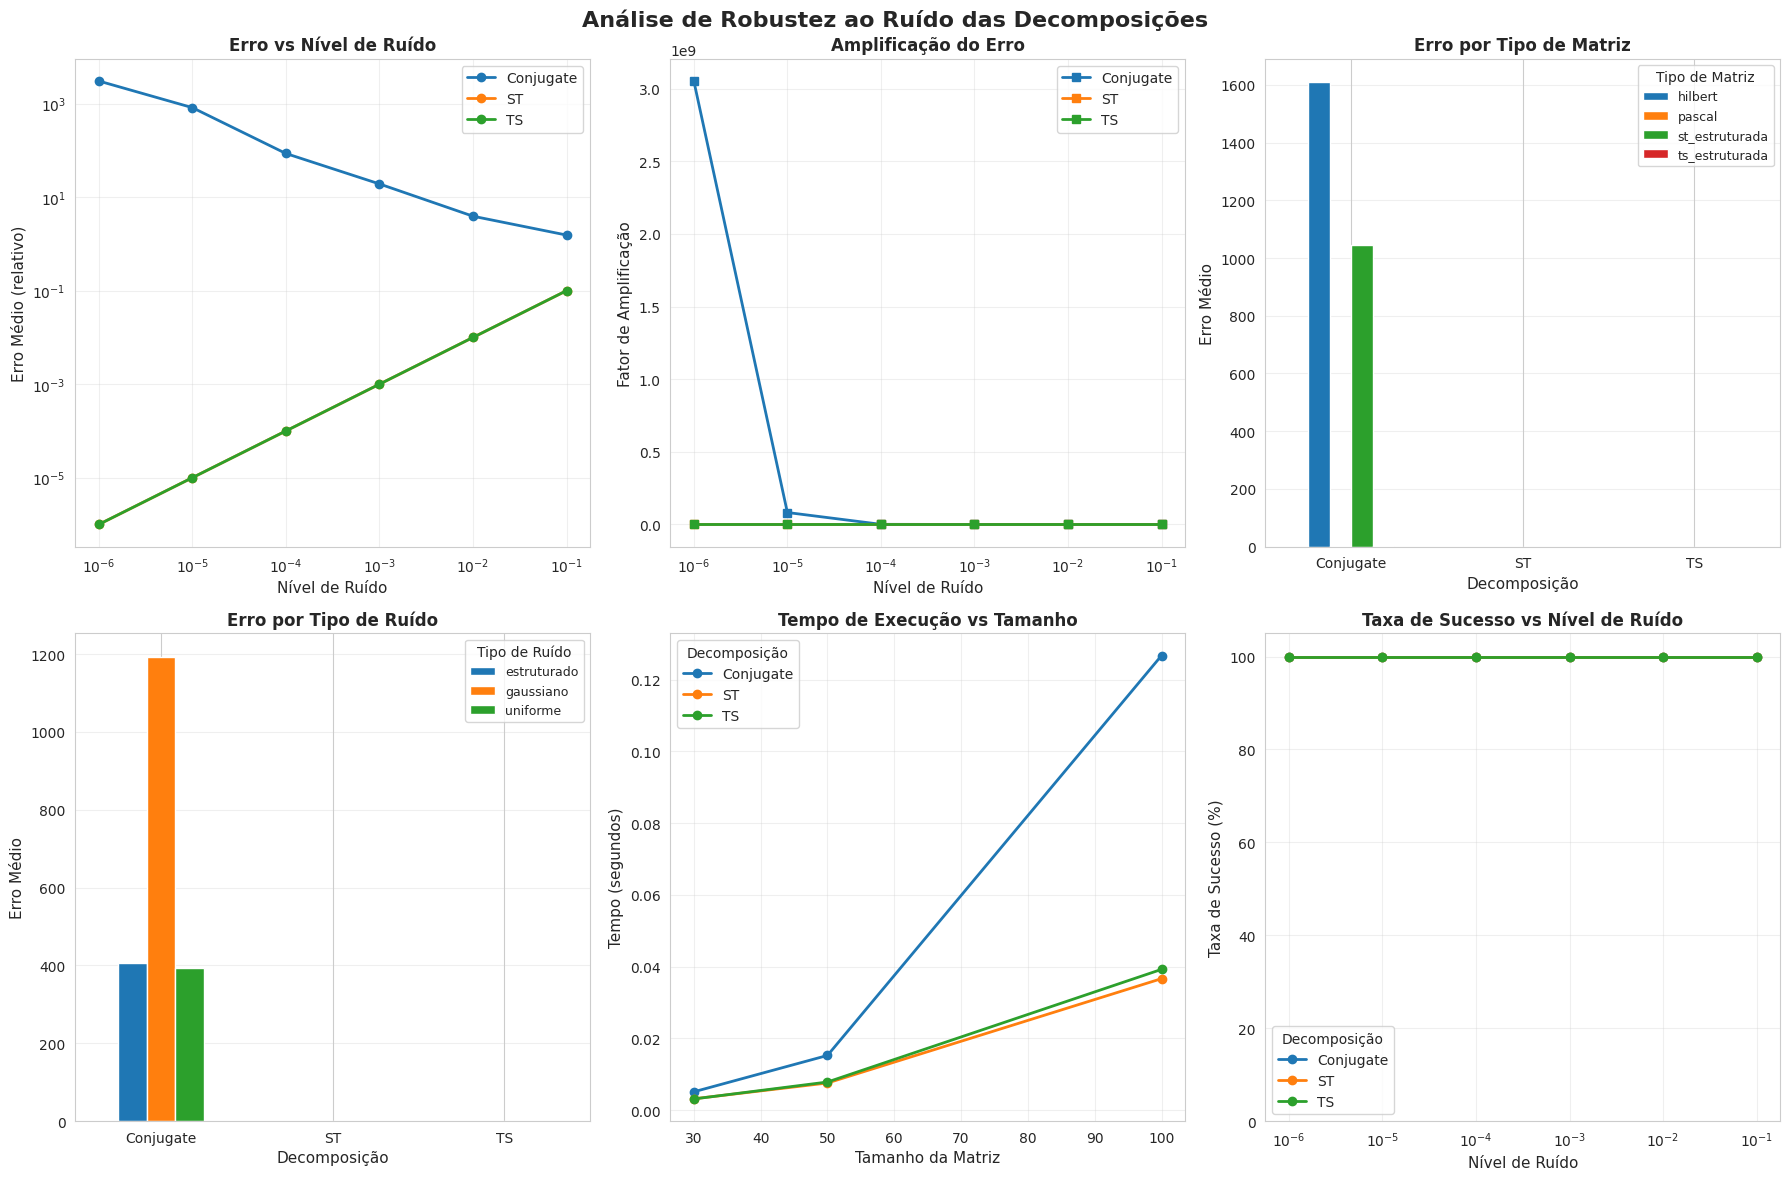

In [ ]:
import numpy as np
from scipy.linalg import orth, solve_triangular, solve
import time
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.linalg import pascal

# ============================================================================
# FUNÇÕES DE GERAÇÃO DE MATRIZES BASE
# ============================================================================

def gerar_matriz_pascal(n, kind='symmetric'):
    """
    Gera uma matriz de Pascal.
    kind: 'symmetric', 'lower', 'upper'
    """
    return pascal(n, kind=kind, exact=False)


def gerar_matriz_hilbert(n):
    """
    Gera uma matriz de Hilbert (mal condicionada).
    H[i,j] = 1/(i+j+1)
    """
    H = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            H[i, j] = 1.0 / (i + j + 1)
    return H


def gerar_matriz_toeplitz(n):
    """
    Gera uma matriz de Toeplitz simétrica.
    """
    primeira_linha = np.random.randn(n)
    from scipy.linalg import toeplitz
    return toeplitz(primeira_linha)


def gerar_matriz_st_estruturada(n, seed=None):
    """
    Gera matriz estruturada para decomposição ST.
    """
    if seed is not None:
        np.random.seed(seed)

    temp = np.random.randn(n, n)
    S = temp @ temp.T + n * np.eye(n)

    T = np.triu(np.random.randn(n, n))
    np.fill_diagonal(T, np.abs(np.diag(T)) + 1)

    return S @ T


def gerar_matriz_ts_estruturada(n, seed=None):
    """
    Gera matriz estruturada para decomposição TS.
    """
    if seed is not None:
        np.random.seed(seed)

    T = np.tril(np.random.randn(n, n))
    np.fill_diagonal(T, 1.0)

    temp = np.random.randn(n, n)
    S = temp @ temp.T + n * np.eye(n)

    return T @ S

# ============================================================================
# FUNÇÕES DE GERAÇÃO DE RUÍDO
# ============================================================================

def adicionar_ruido_gaussiano(A, nivel_ruido, seed=None):
    """
    Adiciona ruído gaussiano à matriz.
    nivel_ruido: proporção do ruído em relação à norma de A

    E = nivel_ruido * ||A||_F * N(0,1) / ||N(0,1)||_F
    """
    if seed is not None:
        np.random.seed(seed)

    norma_A = np.linalg.norm(A, 'fro')
    E = np.random.randn(*A.shape)
    norma_E = np.linalg.norm(E, 'fro')

    # Escalar o ruído para ter a proporção desejada
    E = (nivel_ruido * norma_A / norma_E) * E

    return A + E, E


def adicionar_ruido_uniforme(A, nivel_ruido, seed=None):
    """
    Adiciona ruído uniforme à matriz.
    """
    if seed is not None:
        np.random.seed(seed)

    norma_A = np.linalg.norm(A, 'fro')
    E = np.random.uniform(-1, 1, A.shape)
    norma_E = np.linalg.norm(E, 'fro')

    E = (nivel_ruido * norma_A / norma_E) * E

    return A + E, E


def adicionar_ruido_estruturado(A, nivel_ruido, tipo='diagonal', seed=None):
    """
    Adiciona ruído estruturado (diagonal, banda, etc.)
    """
    if seed is not None:
        np.random.seed(seed)

    norma_A = np.linalg.norm(A, 'fro')
    n = A.shape[0]

    if tipo == 'diagonal':
        E = np.diag(np.random.randn(n))
    elif tipo == 'banda':
        E = np.diag(np.random.randn(n))
        if n > 1:
            E += np.diag(np.random.randn(n-1), k=1)
            E += np.diag(np.random.randn(n-1), k=-1)
    else:
        E = np.random.randn(*A.shape)

    norma_E = np.linalg.norm(E, 'fro')
    E = (nivel_ruido * norma_A / norma_E) * E

    return A + E, E


# ============================================================================
# FUNÇÕES DE TESTE COM RUÍDO
# ============================================================================

def testar_decomposicao_com_ruido(A_original, decomp_func, tipo_decomp,
                                   nivel_ruido, tipo_ruido='gaussiano', seed=None):
    """
    Testa uma decomposição com ruído.

    Retorna métricas de erro e tempo.
    """
    # Adicionar ruído
    if tipo_ruido == 'gaussiano':
        A_ruidosa, E = adicionar_ruido_gaussiano(A_original, nivel_ruido, seed)
    elif tipo_ruido == 'uniforme':
        A_ruidosa, E = adicionar_ruido_uniforme(A_original, nivel_ruido, seed)
    else:
        A_ruidosa, E = adicionar_ruido_estruturado(A_original, nivel_ruido,
                                                    tipo='diagonal', seed=seed)

    # Executar decomposição
    inicio = time.time()
    try:
        if tipo_decomp == 'conjugate':
            Q, Gamma, P = decomp_func(A_ruidosa)
            A_reconstruida = Q @ Gamma @ P.T
        elif tipo_decomp == 'st':
            S, T = decomp_func(A_ruidosa)
            A_reconstruida = S @ T
        else:  # ts
            T, S = decomp_func(A_ruidosa)
            A_reconstruida = T @ S

        tempo = time.time() - inicio

        # Calcular erros
        # Erro de reconstrução em relação à matriz ruidosa
        erro_reconstrucao = np.linalg.norm(A_ruidosa - A_reconstruida, 'fro') / np.linalg.norm(A_ruidosa, 'fro')

        # Erro em relação à matriz original (estabilidade)
        erro_original = np.linalg.norm(A_original - A_reconstruida, 'fro') / np.linalg.norm(A_original, 'fro')

        # Norma do ruído relativa
        norma_ruido_relativa = np.linalg.norm(E, 'fro') / np.linalg.norm(A_original, 'fro')

        # Fator de amplificação do erro
        fator_amplificacao = erro_original / norma_ruido_relativa if norma_ruido_relativa > 0 else np.inf

        return {
            'sucesso': True,
            'tempo': tempo,
            'erro_reconstrucao': erro_reconstrucao,
            'erro_original': erro_original,
            'norma_ruido_relativa': norma_ruido_relativa,
            'fator_amplificacao': fator_amplificacao
        }

    except Exception as e:
        tempo = time.time() - inicio
        return {
            'sucesso': False,
            'tempo': tempo,
            'erro_reconstrucao': np.nan,
            'erro_original': np.nan,
            'norma_ruido_relativa': nivel_ruido,
            'fator_amplificacao': np.nan,
            'erro': str(e)
        }


# ============================================================================
# ESTUDO COMPLETO DE ROBUSTEZ
# ============================================================================

def estudo_robustez_completo():
    """
    Executa um estudo completo de robustez ao ruído.
    """
    # Configurações do estudo
    tamanhos = [30, 50, 100]
    niveis_ruido = [1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1]
    tipos_ruido = ['gaussiano', 'uniforme', 'estruturado']
    tipos_matriz = ['pascal', 'hilbert', 'st_estruturada', 'ts_estruturada']

    resultados = []

    for tamanho in tamanhos:
        for tipo_matriz in tipos_matriz:

            # Gerar matriz base
            if tipo_matriz == 'pascal':
                A_base = gerar_matriz_pascal(tamanho, kind='symmetric')
            elif tipo_matriz == 'hilbert':
                A_base = gerar_matriz_hilbert(tamanho)
            elif tipo_matriz == 'st_estruturada':
                A_base = gerar_matriz_st_estruturada(tamanho, seed=42)
            else:  # ts_estruturada
                A_base = gerar_matriz_ts_estruturada(tamanho, seed=42)

            # Calcular número de condição
            cond_number = np.linalg.cond(A_base)

            for tipo_ruido in tipos_ruido:

                for nivel in niveis_ruido:
                    # Teste Conjugate
                    if tipo_matriz in ['pascal', 'hilbert', 'st_estruturada', 'ts_estruturada']:
                        resultado = testar_decomposicao_com_ruido(
                            A_base, conjugate_decomposition_definitivo,
                            'conjugate', nivel, tipo_ruido, seed=42
                        )
                        resultado.update({
                            'tamanho': tamanho,
                            'tipo_matriz': tipo_matriz,
                            'tipo_ruido': tipo_ruido,
                            'nivel_ruido': nivel,
                            'decomposicao': 'Conjugate',
                            'cond_number': cond_number
                        })
                        resultados.append(resultado)

                    # Teste ST
                    if tipo_matriz in ['pascal', 'st_estruturada']:
                        resultado = testar_decomposicao_com_ruido(
                            A_base, st_decomposition_final,
                            'st', nivel, tipo_ruido, seed=42
                        )
                        resultado.update({
                            'tamanho': tamanho,
                            'tipo_matriz': tipo_matriz,
                            'tipo_ruido': tipo_ruido,
                            'nivel_ruido': nivel,
                            'decomposicao': 'ST',
                            'cond_number': cond_number
                        })
                        resultados.append(resultado)

                    # Teste TS
                    if tipo_matriz in ['pascal', 'ts_estruturada']:
                        resultado = testar_decomposicao_com_ruido(
                            A_base, ts_decomposition_final,
                            'ts', nivel, tipo_ruido, seed=42
                        )
                        resultado.update({
                            'tamanho': tamanho,
                            'tipo_matriz': tipo_matriz,
                            'tipo_ruido': tipo_ruido,
                            'nivel_ruido': nivel,
                            'decomposicao': 'TS',
                            'cond_number': cond_number
                        })
                        resultados.append(resultado)

    return pd.DataFrame(resultados)

# ============================================================================
# ANÁLISE E VISUALIZAÇÃO
# ============================================================================

def analisar_resultados(df):
    """
    Analisa e apresenta os resultados do estudo de robustez.
    """
    # Filtrar apenas sucessos
    df_sucesso = df[df['sucesso'] == True].copy()

    # 1. Taxa de sucesso por decomposição e nível de ruído
    taxa_sucesso = df.groupby(['decomposicao', 'nivel_ruido'])['sucesso'].mean() * 100
    # 2. Erro médio de reconstrução
    erro_medio_reconstr = df_sucesso.groupby(['decomposicao', 'nivel_ruido'])['erro_reconstrucao'].mean()
    # 3. Erro em relação à matriz original
    erro_medio_original = df_sucesso.groupby(['decomposicao', 'nivel_ruido'])['erro_original'].mean()
    # 4. Fator de amplificação médio
    fator_medio = df_sucesso.groupby(['decomposicao', 'nivel_ruido'])['fator_amplificacao'].mean()
    # 5. Análise por tipo de matriz
    erro_por_matriz = df_sucesso.groupby(['decomposicao', 'tipo_matriz'])['erro_original'].mean()
    # 6. Análise por tipo de ruído
    erro_por_ruido = df_sucesso.groupby(['decomposicao', 'tipo_ruido'])['erro_original'].mean()
    # 7. Tempo médio de execução
    tempo_medio = df_sucesso.groupby(['decomposicao', 'tamanho'])['tempo'].mean()

    return df_sucesso


def criar_visualizacoes(df):
    """
    Cria visualizações dos resultados.
    """
    df_sucesso = df[df['sucesso'] == True].copy()

    # Configurar estilo
    sns.set_style("whitegrid")
    plt.rcParams['figure.figsize'] = (15, 10)

    # Criar figura com subplots
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    fig.suptitle('Análise de Robustez ao Ruído das Decomposições', fontsize=16, fontweight='bold')

    # 1. Erro vs Nível de Ruído
    ax1 = axes[0, 0]
    for decomp in df_sucesso['decomposicao'].unique():
        data = df_sucesso[df_sucesso['decomposicao'] == decomp]
        grouped = data.groupby('nivel_ruido')['erro_original'].mean()
        ax1.loglog(grouped.index, grouped.values, marker='o', label=decomp, linewidth=2)
    ax1.set_xlabel('Nível de Ruído', fontsize=11)
    ax1.set_ylabel('Erro Médio (relativo)', fontsize=11)
    ax1.set_title('Erro vs Nível de Ruído', fontsize=12, fontweight='bold')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # 2. Fator de Amplificação vs Nível de Ruído
    ax2 = axes[0, 1]
    for decomp in df_sucesso['decomposicao'].unique():
        data = df_sucesso[df_sucesso['decomposicao'] == decomp]
        grouped = data.groupby('nivel_ruido')['fator_amplificacao'].mean()
        ax2.semilogx(grouped.index, grouped.values, marker='s', label=decomp, linewidth=2)
    ax2.set_xlabel('Nível de Ruído', fontsize=11)
    ax2.set_ylabel('Fator de Amplificação', fontsize=11)
    ax2.set_title('Amplificação do Erro', fontsize=12, fontweight='bold')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    # 3. Erro por Tipo de Matriz
    ax3 = axes[0, 2]
    erro_matriz = df_sucesso.groupby(['decomposicao', 'tipo_matriz'])['erro_original'].mean().unstack()
    erro_matriz.plot(kind='bar', ax=ax3, rot=0)
    ax3.set_xlabel('Decomposição', fontsize=11)
    ax3.set_ylabel('Erro Médio', fontsize=11)
    ax3.set_title('Erro por Tipo de Matriz', fontsize=12, fontweight='bold')
    ax3.legend(title='Tipo de Matriz', fontsize=9)
    ax3.grid(True, alpha=0.3, axis='y')

    # 4. Erro por Tipo de Ruído
    ax4 = axes[1, 0]
    erro_ruido = df_sucesso.groupby(['decomposicao', 'tipo_ruido'])['erro_original'].mean().unstack()
    erro_ruido.plot(kind='bar', ax=ax4, rot=0)
    ax4.set_xlabel('Decomposição', fontsize=11)
    ax4.set_ylabel('Erro Médio', fontsize=11)
    ax4.set_title('Erro por Tipo de Ruído', fontsize=12, fontweight='bold')
    ax4.legend(title='Tipo de Ruído', fontsize=9)
    ax4.grid(True, alpha=0.3, axis='y')

    # 5. Tempo de Execução vs Tamanho
    ax5 = axes[1, 1]
    tempo_tamanho = df_sucesso.groupby(['decomposicao', 'tamanho'])['tempo'].mean().unstack()
    tempo_tamanho.T.plot(kind='line', marker='o', ax=ax5, linewidth=2)
    ax5.set_xlabel('Tamanho da Matriz', fontsize=11)
    ax5.set_ylabel('Tempo (segundos)', fontsize=11)
    ax5.set_title('Tempo de Execução vs Tamanho', fontsize=12, fontweight='bold')
    ax5.legend(title='Decomposição')
    ax5.grid(True, alpha=0.3)

    # 6. Taxa de Sucesso
    ax6 = axes[1, 2]
    taxa = df.groupby(['decomposicao', 'nivel_ruido'])['sucesso'].mean() * 100
    taxa_pivot = taxa.unstack(level=0)
    taxa_pivot.plot(kind='line', marker='o', ax=ax6, linewidth=2)
    ax6.set_xscale('log')
    ax6.set_xlabel('Nível de Ruído', fontsize=11)
    ax6.set_ylabel('Taxa de Sucesso (%)', fontsize=11)
    ax6.set_title('Taxa de Sucesso vs Nível de Ruído', fontsize=12, fontweight='bold')
    ax6.legend(title='Decomposição')
    ax6.grid(True, alpha=0.3)
    ax6.set_ylim([0, 105])

    plt.tight_layout()
    plt.savefig('analise_robustez_ruido.png', dpi=300, bbox_inches='tight')
    return fig

def criar_tabela_resumo(df):
    """
    Cria uma tabela resumo dos resultados.
    """
    df_sucesso = df[df['sucesso'] == True].copy()

    # Criar resumo por decomposição
    resumo = df_sucesso.groupby('decomposicao').agg({
        'erro_reconstrucao': ['mean', 'std', 'min', 'max'],
        'erro_original': ['mean', 'std', 'min', 'max'],
        'fator_amplificacao': ['mean', 'std', 'min', 'max'],
        'tempo': ['mean', 'std'],
        'sucesso': 'count'
    }).round(6)

    print("\n--- RESUMO ESTATÍSTICO POR DECOMPOSIÇÃO ---")
    print(resumo)

    # Resumo por nível de ruído
    resumo_ruido = df_sucesso.groupby(['decomposicao', 'nivel_ruido']).agg({
        'erro_original': 'mean',
        'fator_amplificacao': 'mean'
    }).round(6)

    print("\n--- ERRO E AMPLIFICAÇÃO POR NÍVEL DE RUÍDO ---")
    print(resumo_ruido)

    return resumo, resumo_ruido

# ============================================================================
# FUNÇÃO PRINCIPAL
# ============================================================================

def executar_estudo_completo():
    """
    Executa o estudo completo de robustez ao ruído.
    """
    print( " ESTUDO COMPLETO DE ROBUSTEZ AO RUÍDO ".center(78) )

    # 1. Executar testes
    df_resultados = estudo_robustez_completo()
    # 2. Análise
    df_analise = analisar_resultados(df_resultados)
    # 3. Visualizações
    fig = criar_visualizacoes(df_resultados)
    # 4. Tabelas e relatório
    resumo, resumo_ruido = criar_tabela_resumo(df_resultados)
    # Salvar DataFrame
    df_resultados.to_csv('resultados_robustez_completo.csv', index=False)

    return df_resultados, fig

# ============================================================================
# EXECUÇÃO
# ============================================================================

if __name__ == "__main__":
    df_resultados, fig = executar_estudo_completo()
    plt.show()